In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from anonymeter.evaluators import InferenceEvaluator 
import sys
parent_dir = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline"
sys.path.append(parent_dir)
from SynOmics.processing.postprocessing import post_masking

import logging
logging.basicConfig(filename="anonymeter_inferences.log", level=logging.DEBUG)

ori = pd.read_csv("OriginalData/integrated_data_final.csv", index_col = 0)
masked_ori = post_masking(ori)
masked_ori.columns = [col.replace('.', '_') for col in masked_ori.columns]

syn_datas = ["synthetic_data_avatars_k5","synthetic_data_avatars_k10","synthetic_data_ctgan","synthetic_data_gauss_copula","synthetic_data_tvae",
             "synthetic_data_synthpop"]
tools = ["AvatarsK5", "AvatarsK10", "CTGAN","GaussianCopula", "TVAE","Synthpop"]
synthetic_dict = {}
for i, tool in enumerate(tools):
    syn_df = pd.read_csv(f"SyntheticData/{syn_datas[i]}.csv", index_col = 0)
    masked_syn_df = post_masking(syn_df)
    masked_syn_df.columns = [col.replace('.', '_') for col in masked_syn_df.columns]
    synthetic_dict[tool] = masked_syn_df

In [3]:
import pickle

with open("results_inferences.pkl", "rb") as f:
    results_inferences = pickle.load(f)

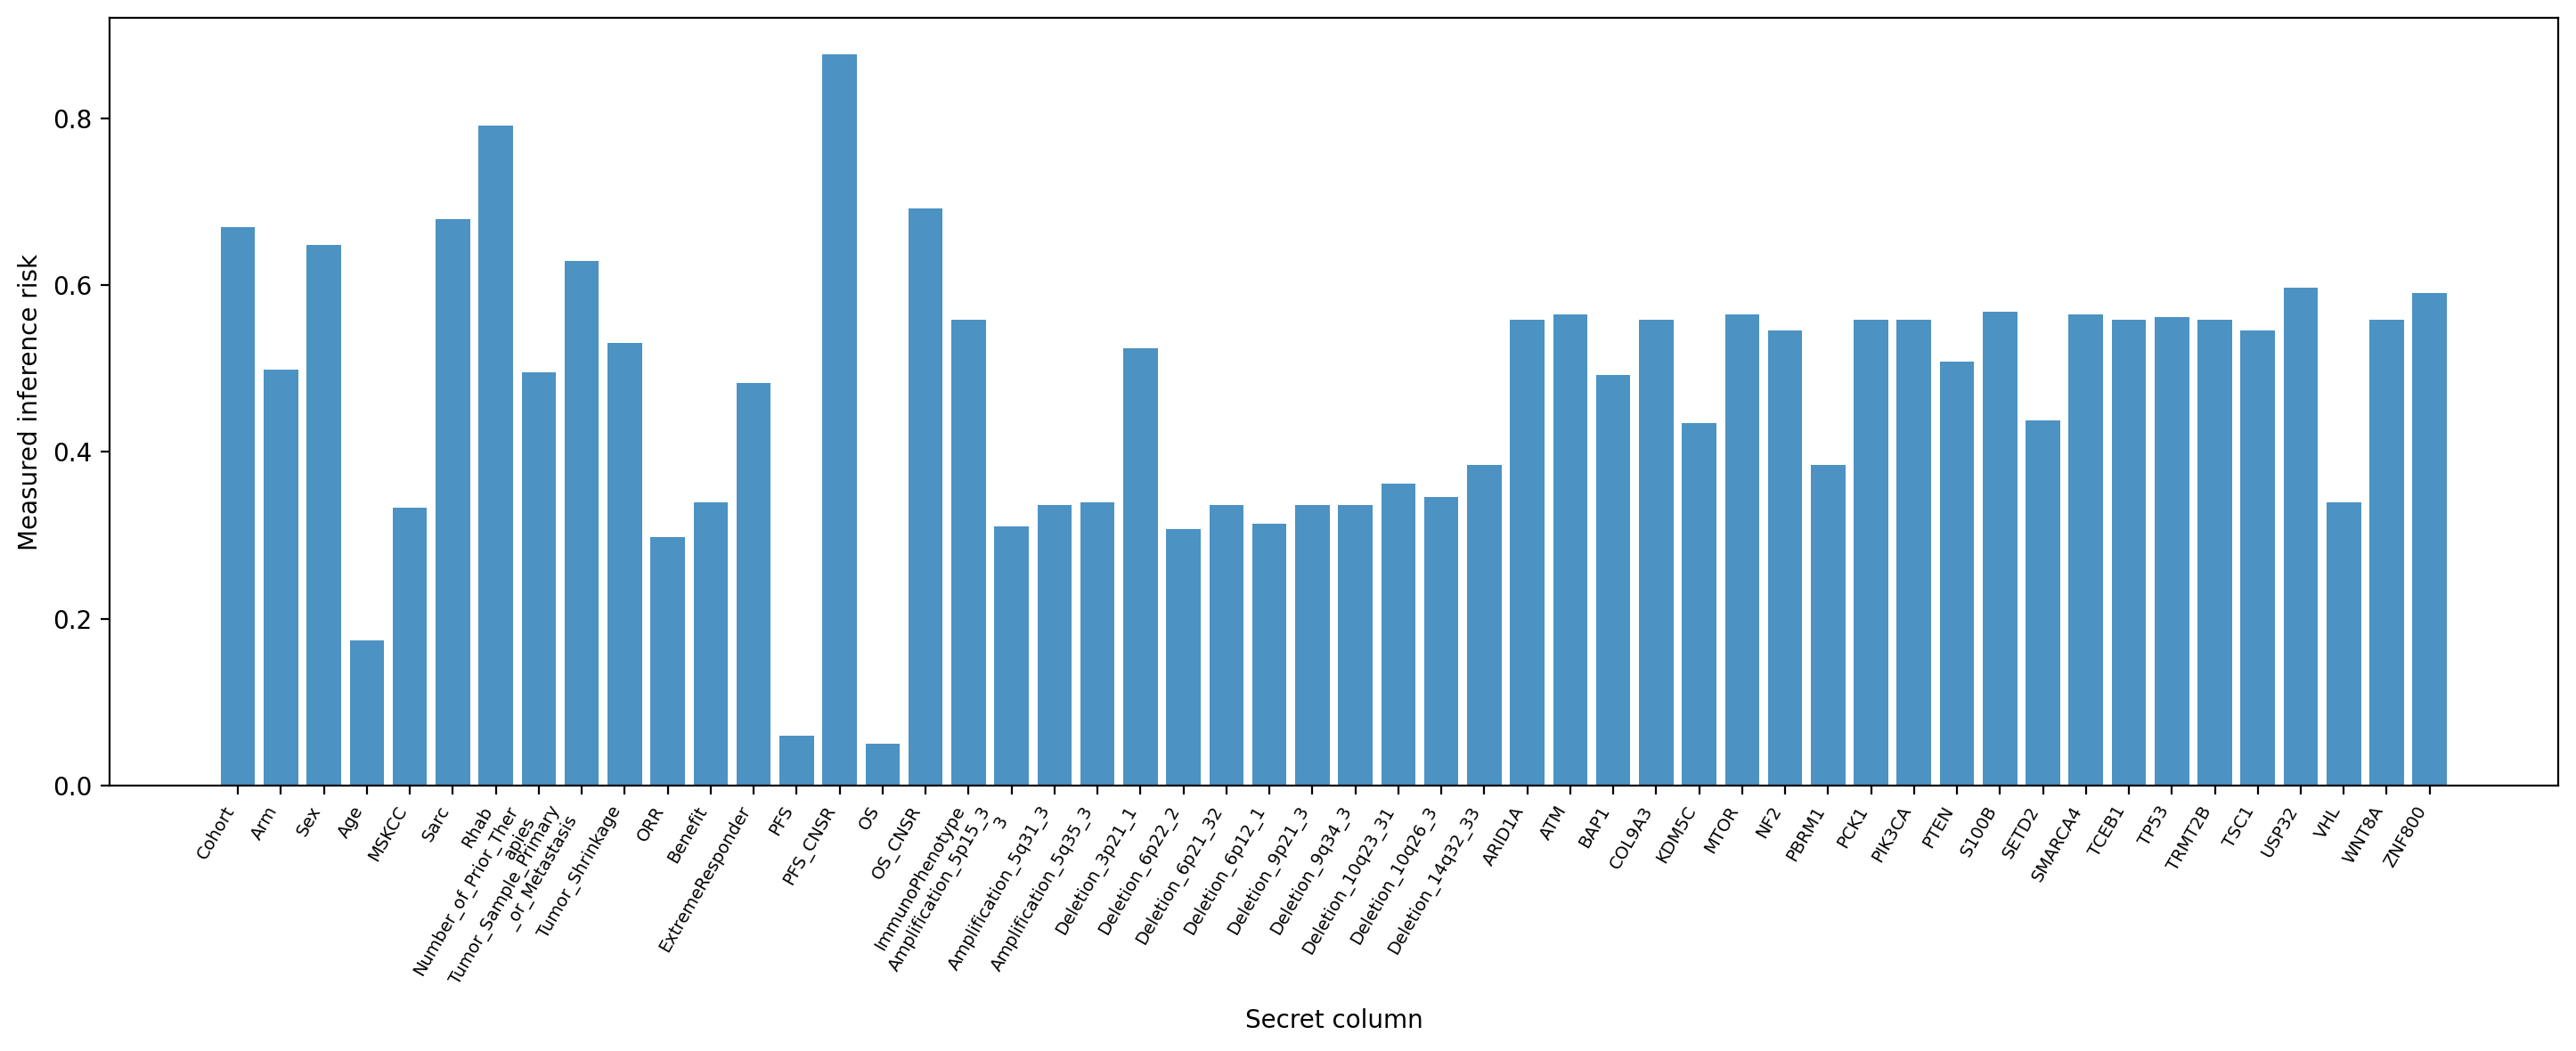

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# data
results = results_inferences["Synthpop"]
risks = [res[1].risk().value for res in results]
columns = [res[0] for res in results]

# Optional: wrap long labels so they occupy multiple lines
wrapped = [ "\n".join(textwrap.wrap(lbl, 20)) for lbl in columns ]

# Dynamic figure width: scale with number of bars
n = len(columns)
fig_w = max(10, n * 0.28)    # tweak the multiplier to taste
fig_h = 6

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=200)  # higher DPI for quality
x = np.arange(n)
ax.bar(x, risks, alpha=0.8, ecolor='black', capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(wrapped, rotation=60, ha='right', fontsize=7)
ax.set_ylabel("Measured inference risk")
ax.set_xlabel("Secret column")

plt.tight_layout()   # ensure labels are not cut off

# Save high-res copy
# plt.savefig("inference_risk_synthpop.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
np.mean(risks)

0.47410173938213823

In [10]:
syn_datas_demo = ["synthetic_data_avatars_k5"]
tools_demo = ["AvatarsK5"]
synthetic_dict_demo = {}
for i, tool in enumerate(tools_demo):
    syn_df = pd.read_csv(f"SyntheticData/{syn_datas[i]}.csv", index_col = 0)
    masked_syn_df = post_masking(syn_df)
    masked_syn_df.columns = [col.replace('.', '_') for col in masked_syn_df.columns]
    synthetic_dict_demo[tool] = masked_syn_df

In [11]:
from tqdm import tqdm
from SynOmics.utils.monitoring import monitor_resources


@monitor_resources
def inferences_genes_clinical(ori, syns):
    cols = ori.columns.tolist()
    
    genes_cols = []
    clinical_cols = []
    for col in cols:
        if col.startswith("ENSG"):
            genes_cols.append(col)
        else:
            clinical_cols.append(col)
    
    
    for tool, syn_data in synthetic_dict.items():
        results_as_tool = {}
        results = []
        print(f"---{tool}---")
        for secret in tqdm(clinical_cols):
            evaluator = InferenceEvaluator(ori=ori, 
                                           syn=syn_data, 
                                           aux_cols=genes_cols,
                                           secret=secret,
                                           n_attacks=ori.shape[0])
            evaluator.evaluate(n_jobs=-2)
            results.append((secret, evaluator.results()))
        
        results_as_tool[tool] = results  
    return results_as_tool

results_inferences = inferences_genes_clinical(masked_ori, synthetic_dict_demo)

--- System & Process Info ---
Current Date and Time (UTC): 2025-10-31 14:15:40
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 32
Logical Processors: 32
Process RAM before execution: 1700.07 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'nvidia-ml-py' is installed and NVIDIA drivers are accessible.
Error: module 'nvidia_smi' has no attribute 'nvidia_smi_lib'

--- Function Execution ---
---AvatarsK5---


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [04:05<00:00, 49.02s/it]


---AvatarsK10---


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [04:05<00:00, 49.19s/it]


---CTGAN---


...

---TVAE---


  0%|                                                                                                                                                                                                                                    | 0/5 [00:00<?, ?it/s]/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.8001510676324837, baseline = 0.8001510676324837. Analysis results cannot be trusted.
  self._sanity_check()
 40%|████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                    | 2/5 [01:37<02:26, 48.73s/it]/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.73

---Synthpop---


  0%|                                                                                                                                                                                                                                    | 0/5 [00:00<?, ?it/s]/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.6699267949030463, baseline = 0.6794554002247125. Analysis results cannot be trusted.
  self._sanity_check()
 20%|████████████████████████████████████████████                                                                                                                                                                                | 1/5 [00:49<03:16, 49.05s/it]/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.49


--- Resource Usage Summary ---
Execution time: 1476.899489 seconds
Process RAM after execution: 1725.14 MB
Process RAM used by function: 25.07 MB
Average per-core CPU during execution: [20.1, 92.7, 30.5, 21.2, 20.3, 18.2, 42.0, 22.1, 33.3, 92.3, 38.1, 92.4, 22.9, 92.1, 20.6, 92.9, 21.0, 92.6, 19.3, 92.7, 21.3, 92.3, 90.5, 92.1, 86.5, 92.4, 91.4, 92.2, 91.7, 22.4, 91.9, 17.7]
CPU Cores utilized (>10%): 32 of 32




In [22]:
import pickle
with open("my_object.pkl", "wb") as f:
    pickle.dump(results_inferences, f)

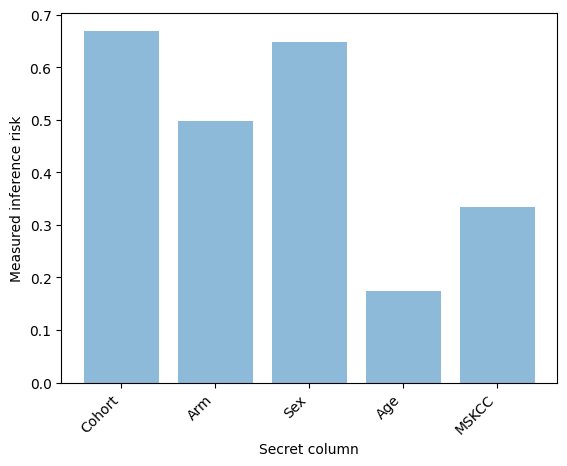

In [21]:
fig, ax = plt.subplots()
results = results_inferences["Synthpop"]
risks = [res[1].risk().value for res in results]
columns = [res[0] for res in results]

ax.bar(x=columns, height=risks, alpha=0.5, ecolor='black', capsize=10)

plt.xticks(rotation=45, ha='right')
ax.set_ylabel("Measured inference risk")
_ = ax.set_xlabel("Secret column")